## T5: Isolated Tip
For this tuturial we proceed as before, with the exeption that we use a so-called realspace selfenergy, meaning we can model a single point in real space in a periodic slab. We utilize a custom calculator from sisl. In particular, we'll model a in contact with a sheet of graphene. For this purpose we will get more manual in the construction of the Hamiltonians needed and run some calculations manually. We now also use explicitly use the siesta_python code, which has been running in the background previously. The code for this is largely reused from the sisl-tutorial on this same topic. 

dep:0: SislDeprecation: SuperCell is deprecated; please use 'Lattice' class instead [>=0.15] [removed in 0.17]
dep:0: SislDeprecation: __init__ argument sc has been deprecated in favor of lattice, please update your code. [>=0.15] [removed in 0.17]
/home/aleks/moss/lib/python3.14/site-packages/seekpath/getpaths.py:427: SupercellWarning: The provided cell is a supercell: the returned k-path is the standard k-path of the associated primitive cell in the basis of the supercell reciprocal lattice.
  warnings.warn(
warn:0: SislWarning: Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    4.9s
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:    8.5s
[Parallel(n_jobs=1)]: Done  12 tasks      | elapsed:   12.8s
[Parallel(n_jobs=1)]: Do

[[0, 3, 4, 7, 8, 11, 12, 23, 24, 25, 26, 29, 30, 33, 34, 35], [np.int64(36), np.int64(37), np.int64(38)]]
Running TB-Trans in Directory: Device!

Normal plot


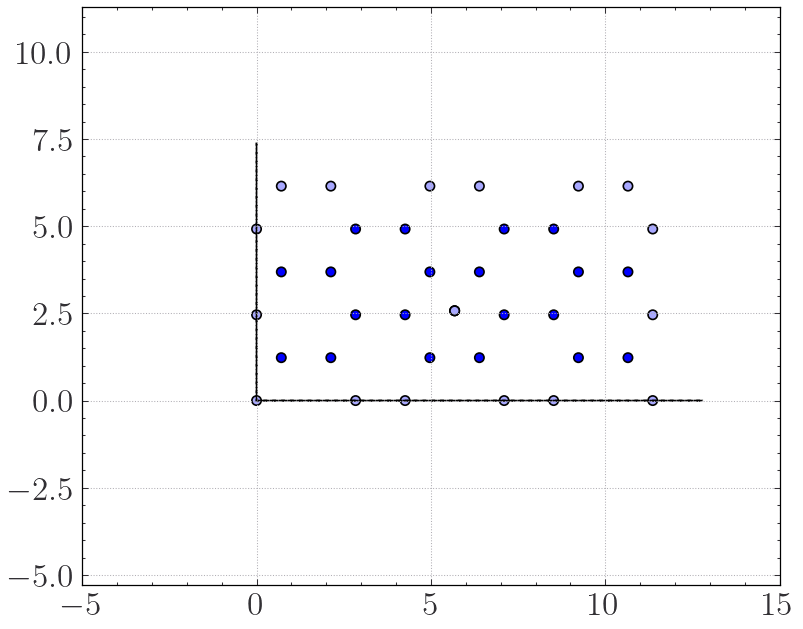

---> Hello! <--- 
It seems like you have used the a real-space self energy! good for you.
This does however mean you need to compute a  rigid shift in the energy-levels in the Hamiltonian!
This is done using the self.Renormalise_H and the find_correction from fitting tools.
This should be covered in a tutorial.
 ----><----
Calculating corrections for electrode 0. (RSSE electrode)
Calculating corrections for electrode 1. (Normal electrode)

 Building ES - H - Self Energies 

[0]
Using S = S

 Overlap Included!



In [1]:
import sisl
import numpy as np
from Zandpack.TimedependentTransport import TD_Transport
from siesta_python.siesta_python import SiP
import matplotlib.pyplot as plt
import matplotlib.image as img

#  sisl geometries:
t1,t2 = 3,3
graphene = sisl.geom.graphene(orthogonal=True)
slab = graphene.tile(t1,0).tile(t2,1)

STM = sisl.Geometry([0, 0, 1], atoms=sisl.Atom('Au', R=1.0001), sc=sisl.SuperCell([10, 10, 1], nsc=[1, 1, 3]))
STM = STM.tile(3,2).move(slab.center() + np.array([0,-0.5, -1]))
tip = STM.tile(1,2)

geom_dev = slab.add(tip)
geom_dev = geom_dev.add_vacuum(40,2)
R  = TD_Transport ([graphene, tip],  geom_dev)
line = np.linspace(-5,5,20)+1j*1e-2
line = np.vstack([line]*2)
R.Make_Contour(line, 15, pole_mode = 'JieHu2011')


# Objects to run tbtrans from:
elec_RS = SiP(graphene.cell,graphene.xyz, graphene.atoms.Z,
             basis = 'SZ', pp_path = '../pp',
             semi_inf='ab',mpi = '',
             directory_name = 'C',sl = 'C', sm = 'C',
             dm_tol = '1.d-6', kp = [20, 20, 1],
             overwrite = True,
             elec_RSSE = True)

stm    = SiP(STM.cell, STM.xyz, STM.atoms.Z,
             basis = 'SZ', pp_path = '../pp', mpi = '',
             semi_inf = '+a3', directory_name = 'Au_tip', sl = 'Au_tip', sm = 'Au_tip',
             dm_tol = '1.d-6', kp = [1,1,20],
             overwrite = True)

Dev    = SiP(geom_dev.cell, geom_dev.xyz, geom_dev.atoms.Z,
             solution_method = 'transiesta',
             basis = 'SZ', pp_path = '../pp',mpi = '',
             directory_name = 'Device', elecs = [elec_RS, stm],
             kp_tbtrans = [1,1,1],
             dm_tol = '1.d-4', kp = [1,1,1],Chem_Pot = [0.0, 0.0],
             overwrite = True, save_SE=True, custom_tbtrans_contour=R.Contour
            )

# Electronic structure
H_grph = sisl.Hamiltonian(graphene)
H_grph.construct([[0.0, 1.45],[0.0, -2.7]])
H_stm = sisl.Hamiltonian(STM)
H_stm.construct([[0.0, 1.45],[0.0, -2.7]])
# Circumvent TranSiesta
elec_RS.manual_H(H_grph)
stm    .manual_H(H_stm)
elec_RS.fdf()
stm    .fdf()
# Run realspace calculation for graphene sheet
elec_RS.Real_space_SE(0,1,(t1,t2,1), 0.0, -0, 0, 2/50, Contour = R.Contour, 
                      parallel_E = True, num_procs=1, )
Dev.find_elec_inds()
# Electronic structure of Device & TBtrans calculation
H_dev = sisl.Hamiltonian(Dev.to_sisl())
H_dev.construct([[0.0, 1.45],[0.0, -2.7]])
Dev.manual_H(H_dev)
Dev.fdf()
Dev.run_tbtrans_in_dir()
plt.show()
Dev.Visualise()

plt.show()
plt.pause(0.1); 
# We give our TD calculator object this device object and we can proceed as usual:
R.Device = Dev
R.read_data()



In [ ]:
# R.reset_all_fits()
def run_mini(its):
    R.Fit(fact = 0.5,  NumL = 12,
          fit_mode = 'all',
              min_method='trust-constr',
              ebounds = (-5.1, 5.1), 
              wbounds = (0.01, 20.0), 
              gbounds = (None, None),
              tol = -1, 
              options = {'disp':True,
                         'maxiter':its, 
                         #'gtol':1e-5, 
                         #'ftol':1e-5, 
                         #'iprint':1
                         },
              fit_real_part = False,
              specific_bounds = None, 
              alpha_PO = 0.1,
              cons = '')


In [ ]:
#help(R.Fit)
run_mini(100)

In [ ]:
R.Inspect_Lorentzian_fit(0, 0,0,0,0, Emin = -7, Emax = 7)
plt.show()
R.Inspect_Poles(0, fermi_poles=False)


In [ ]:
R.fitted_lorentzians[1].is_zero

In [ ]:
R.Inspect_transmission_from_hilbert_transform(eta = 1e-3, E = np.linspace(-15,15,1800)) 

In [ ]:
R.tofile('RSSE')

In [ ]:
!SCF Dir=$PWD file=RSSE
!psinought Dir=$PWD file=RSSE
!mpirun -np 3 zand Dir=$PWD


In [ ]:
!td_info Dir=$PWD file=RSSE plotcurrent=1 label=Current format=png
im = img.imread('CurrentCurrentplot.png')
plt.rcParams['figure.figsize']=(15,9)
plt.imshow(im)


In [ ]:
plt.plot(t2, data2['current_left'])
plt.plot(t2, data2['current_right'])



In [ ]:
plt.plot(t2, data2['current_left'])
plt.plot(t2, data2['current_right'])


In [ ]:
dir(R)

In [ ]:
help(elec_RS.Real_space_SE)

In [ ]:
help(elec_RS.Real_space_SE)